In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure src modules can be imported
sys.path.append(str(Path.cwd().parent))

from src.utils.paths import get_path
from src.data.loader import load_and_merge_data

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Define save directories
eda_assets_dir = get_path("data", "raw").parent.parent / "assets" / "eda"
eda_results_dir = get_path("results", "eda")
eda_assets_dir.mkdir(parents=True, exist_ok=True)
eda_results_dir.mkdir(parents=True, exist_ok=True)

In [2]:
print("Loading dataset...")
df = load_and_merge_data()

print(f"Dataset Shape: {df.shape}")
print("\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Basic memory usage
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Loading dataset...
Loading benign.csv...
Found 8 files in attacks directory.

--- Dataset Class Distribution ---
0 (Benign):    797626
1 (Malicious): 674290
----------------------------------

Dataset Shape: (1471916, 46)

Missing Values:
Series([], dtype: int64)

Memory Usage: 3850.63 MB


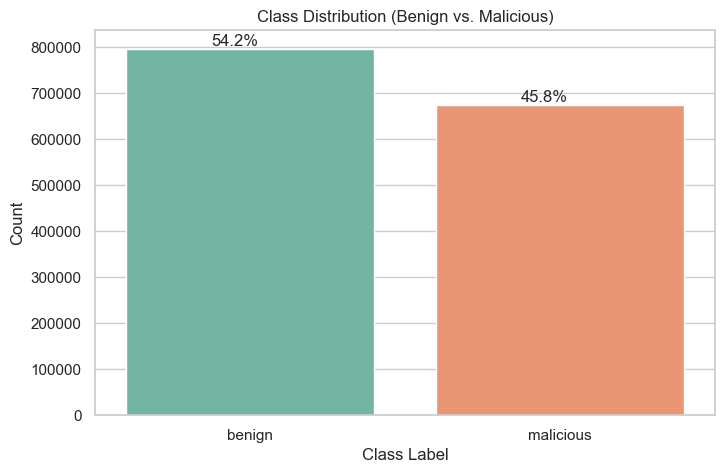

Class Counts:
label
benign       797626
malicious    674290
Name: count, dtype: int64

Decision: Based on this ratio, we must use Macro F1, ROC-AUC, and PR-AUC for model evaluation, not raw accuracy.


In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label', palette='Set2')
plt.title("Class Distribution (Benign vs. Malicious)")
plt.xlabel("Class Label")
plt.ylabel("Count")

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.savefig(eda_assets_dir / "class_distribution.png", bbox_inches='tight')
plt.savefig(eda_results_dir / "class_distribution.png", bbox_inches='tight')
plt.show()

print("Class Counts:")
print(df['label'].value_counts())
print("\nDecision: Based on this ratio, we must use Macro F1, ROC-AUC, and PR-AUC for model evaluation, not raw accuracy.")

In [4]:
from src.data.cleaning import drop_non_feature_columns

# Isolate just the features for duplicate checking
features_df = drop_non_feature_columns(df)

# Find rows that have the exact same feature values
duplicate_mask = features_df.duplicated(keep=False)
duplicates_full = df[duplicate_mask]

# Check if identical features have contradicting labels
conflicting_labels = duplicates_full.groupby(list(features_df.columns))['label'].nunique()
conflicts = conflicting_labels[conflicting_labels > 1]

print(f"Total duplicate feature rows: {duplicate_mask.sum()}")
print(f"Number of feature combinations with conflicting labels (both benign and malicious): {len(conflicts)}")

if len(conflicts) > 0:
    print("WARNING: Dataset contains identical feature vectors with differing labels. This requires cleaning in Stage 4/Data Pipeline.")
else:
    print("Clean: No cross-class exact duplicates found.")

Total duplicate feature rows: 1117
Number of feature combinations with conflicting labels (both benign and malicious): 0
Clean: No cross-class exact duplicates found.


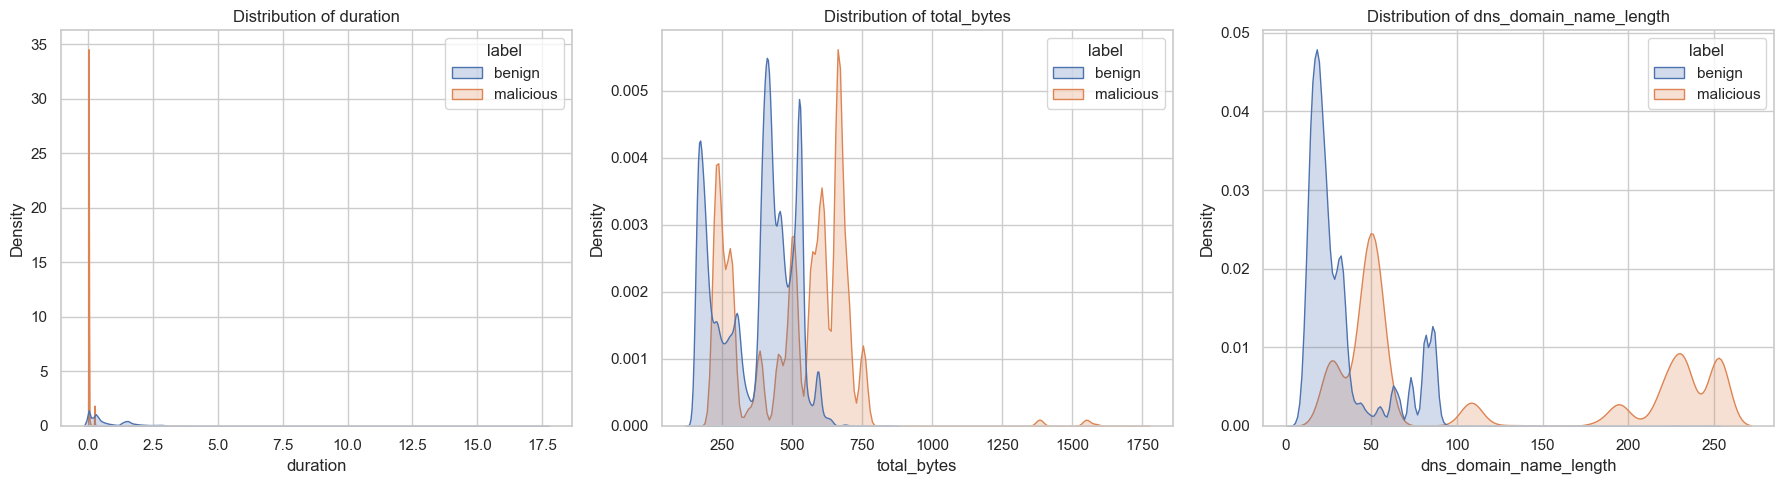

In [5]:
features_to_plot = ['duration', 'total_bytes', 'dns_domain_name_length']
existing_features = [f for f in features_to_plot if f in df.columns]

if existing_features:
    fig, axes = plt.subplots(1, len(existing_features), figsize=(18, 5))
    if len(existing_features) == 1:
        axes = [axes]
        
    for ax, feature in zip(axes, existing_features):
        sns.kdeplot(data=df, x=feature, hue='label', common_norm=False, ax=ax, fill=True)
        ax.set_title(f'Distribution of {feature}')
        # Log scale if heavily skewed
        if df[feature].skew() > 3:
            ax.set_xscale('log')
            
    plt.tight_layout()
    plt.savefig(eda_assets_dir / "trivial_separability_check.png")
    plt.savefig(eda_results_dir / "trivial_separability_check.png")
    plt.show()

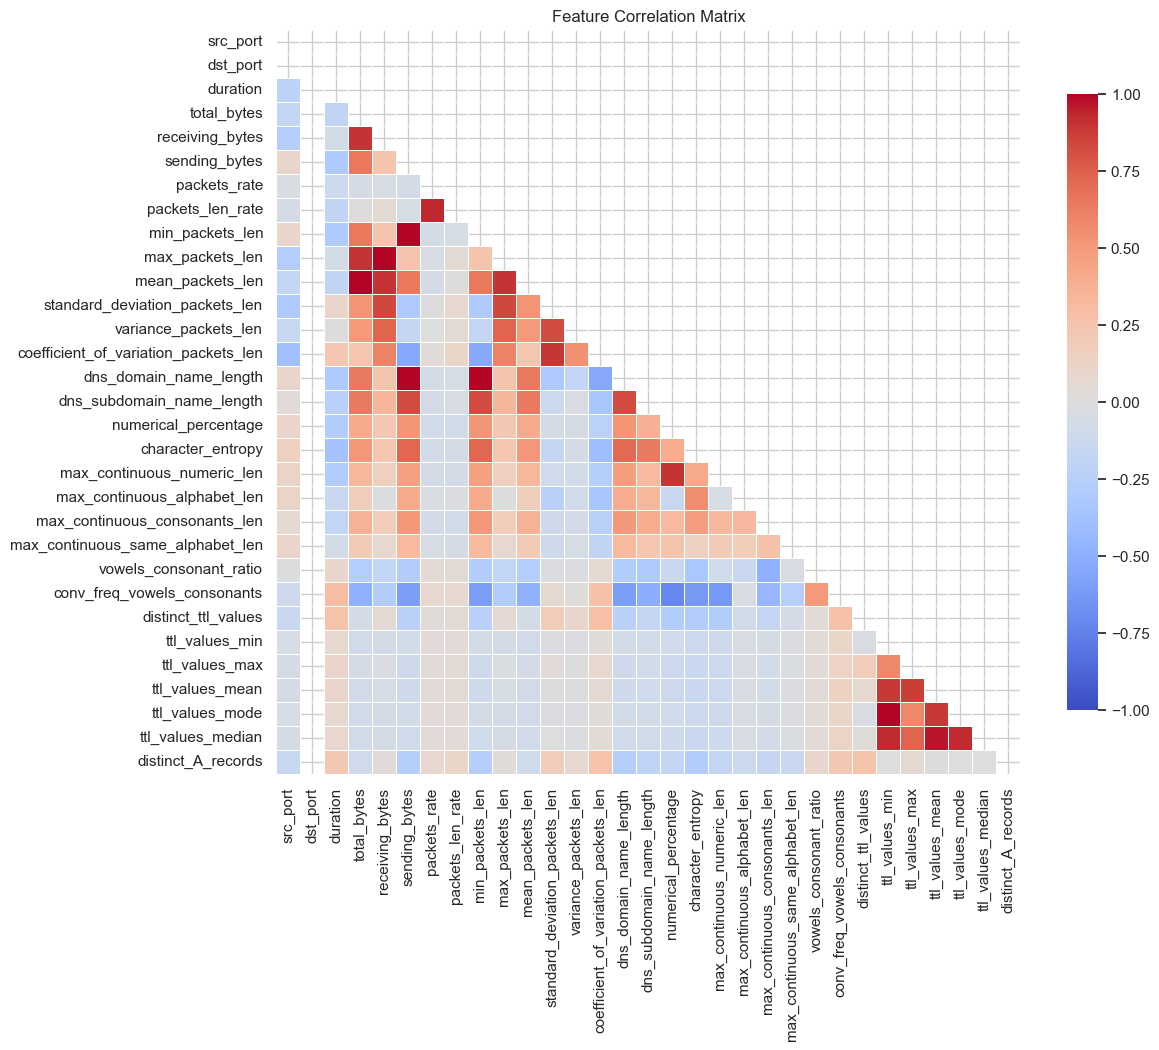

In [6]:
plt.figure(figsize=(12, 10))

# Compute correlation only on numeric features
numeric_features = features_df.select_dtypes(include=[np.number])
corr = numeric_features.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1.0, vmin=-1.0, 
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Feature Correlation Matrix")
plt.savefig(eda_assets_dir / "correlation_matrix.png", bbox_inches='tight')
plt.savefig(eda_results_dir / "correlation_matrix.png", bbox_inches='tight')
plt.show()